# Project - Projectile 1

---

In this project, we aim to apply supervised machine learning techniques to a classic problem in physics: predicting the horizontal distance traveled by a projectile. The objective is to build predictive models for two related but distinct tasks. 

- For Project 1, the goal is to predict the horizontal distance based on the initial velocity components along the x and y axes ($v_x$ and $v_y$). 
- For Project 2, the model will predict the horizontal distance using the magnitude of the initial velocity ($v$) and the launch angle ($\theta$). 

Both tasks involve training regression models on simulated projectile data, with the ultimate aim of accurately capturing the underlying physical relationships from example data. We will see that one given system when trained for different problems shows the flexibility to adapt to different situations.


## 1. Overview

Recall key ingredients in supervised machine learning:

- Task (T)
- Experience (E)
- Performance measure (P)
- Hypothesis Space (Machine learning model)
- Learning Algorithm 
- Generalisation

We will go through all these elements in detail with Project 1, and then apply those concepts and techniques to Project 2

## 2. Project-1: horizontal distance from the initial velocity components ($v_x$ & $v_y$)

### 2.1 Define the task for Machine Learning via "_target function_"

In supervised machine learning, the goal is always to infer from data ("experience") the relation between two sets of variables called "**features**" and "**labels**" (also called "**targets**") of some subject. Both **feature** and **label** can be composed by multiple quantities or variables, where each variable represents some property of the subject. 

> In the current project, 
> 
> - the "subject" under investigation is the projectile launched under the effect of gravity, 
> - the "features" is the pair of launching velocity components $(v_x,\; v_y)$, and 
> - the "label" is the horizontal distance (i.e. along $x$) of the projectile landing position from the launching point, denoted $d$.

The task meant for a supervised learning system is to return as accurately as possible the **label** when a **feature** compressing a set of pre-conventioned variables is provided. Thus from the machine's perspective, the **features** are alternatively called "**input**" and the **label** is alternatively called "**output**". 

Mapping from the **feature** to the **label** for a subject in the real world is the **target function**. It is the _true association of a label to some features_, i.e. the **target function**, that is meant to be learned by a machine. 

The **target function**, denoted $f_T(\cdot)$, is specified by 

- the form of the "feature" (or "input") -- the _domain of definition_ and the meaning for each of its variables.
- the form of the "label" (or "output") -- the _domain of definition_ and the meaning for each of its variables. 

> In the current project, the target function $f_T(\cdot)$ is specified by 
> - the feature domain $X\hat{=}\{ (v_x, v_y) | v_x \in \mathbb{R}^+, \; v_y \in \mathbb{R}^+ \}$ where $v_x$ and $v_y$ are respectively the horizonal and vertical components of the launching velocity, and 
> - the label domain $Y\hat{=}\{d|d\in \mathbb{R}^+\}$ where $d$ represents the landing distance of the projectile.
> 
> The target function is formally  $$ f_T:X\rightarrow Y \quad \text{or} \quad f_T(v_x, v_y) = d$$
>
> In the majority of situations, unlike the current projectile problem where the target function can be resolved (using physics), the target function is too complex to be resolved, and the task of supervised machine learning is to infer that unknown **target function** using certain techniques with available data.   

**_Specifying the target function defines the task intended for a machine learning system_**. It leads to crucial indications for 

1. The data pipeline : the entire process from raw data collection to the formation of training and testing datasets ready for training and testing machine learning models. 
2. The hypothesis space: the scope of the candidating machine learning models to be used, that is models that can map from the feature domain $X$ to the label domain $Y$.
3. The performance measure definition: when a target $\hat t$ output by a machine learning system mismatches the true target $t$, one needs to specify the so called **loss function**, denoted $L(\cdot, \cdot)$ mapping $(t,\hat t)\in Y^2$ to some domain of scalar usually $\mathbb{R}^+$. 

### 2.2 Data exploration

Once the target function is well specified, also clarified is the final product of the data pipeline, i.e. an ensemble of observed "feature-target" pairs. In practice, if no raw data is provided, one needs to design the data collection and cleaning up process in order to produce the ready-to-use "feature-target" pairs, or else one shall transform the raw data into the form of "feature-target" pairs required by the target function. 

In this current project, the final product of data pipeline, i.e. feature-target pairs, is prepared ready in `/training_set_1.dat` for you to proceed further machine learning steps.

Once the training dataset of feature-target pairs is ready, it is helpful to perform the so-called "**data exploration**" to gain insights of the connections among all variables (in both feature and target) for a wise direction in picking up machine learning models. 

**Data exploration**, in principle, should be directed by generic questions about the internal mechanism underlying the subject, which varies with case and approach. Here, we will go over some common procedures for data exploration through a series of exercises and derive some insights for picking up machine learning models for the current project.

#### **Exercise 2.2.1** Load data

Load the following data files with `numpy.loadtxt` function:
  - "training_set_1.dat"
  - "test_set_1.dat" 

1. Explore the loaded data structure. How many entries "feature-target" pairs in each dataset?
2. Explore the header of the data files, and determine which columns are the inputs (features) and which columns are the output (targets)?

Using the code cell below. Reminder: you can use `help()`, `dir()` and `type()` for the manual of new objects in Python.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib widget

# Load data files
train1 = np.loadtxt('./training_set_1.dat')
test1 = np.loadtxt('./test_set_1.dat')

# pop1_root = np.loadtxt('/population_1.dat')
# pop1_current = np.loadtxt('./population_1.dat')

# # data structure, how many columns and rows?
print(train1.shape)
print(test1.shape)

# # header of the data files, which columns are the inputs and which are the output?

# print the element on 54th line and 2nd column
print(train1[53,1])

# print the elements from the 54th to 64th line and on the 2nd column
print(train1[53:64, 1])

# print the elements from the 1st to 10th line and all the columns
print(train1[0:10, :])

print(train1[:3,1:])

# # print the first 100 lines of the 1st column
# print('100 elements of the 1st column')
# print(train1[:100, 0])

vx = train1[:,0]
vy = train1[:,1]
# print the max and the min of vx
print('the max of vx is ', np.max(vx))
print('the min of vx is ', np.min(vx))

# print the max and the min of vy
print('the max of vy is ', np.max(vy))
print('the min of vy is ', np.min(vy))


N = 10000
X = np.random.normal(5,2,N)
# print('X: ', X)
print('min of X ', np.min(X))
print('max of X ', np.max(X))
print('intervals: ', np.linspace(np.min(X), np.max(X), 5))

plt.hist(X, bins=30, density=True)


#### **Exercise 2.2.2** Distribution of the input variables

With the help of `matplotlib`, exploring the following aspect of the input variables (feature variables) in `training_set_1.dat`:

1. For each variable in the feature, what is its empirical distribution? Hint: one can plot the histogram using `matplotlib.pyplot.hist`.
2. Is there a most probable value each input variable may take?
3. Estimate the expectation of each input variable.
4. Estimate the fluctuation of each input variable around its expectation.
5. How to transform an input variable such that it has zero expectation and unity standard deviation? Such a transformation is called "normalisation".

Use the following code cell for this exercise.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# %matplotlib widget
# for interactive plotting

# load the training set and declare input variables
# train1 = np.loadtxt(..)
vx = train1[:,0]
vy = train1[:,1]

# Distribution of the input variables by ploting the histogram of vx and vy
Hist = plt.hist(vx, bins=30, density=True, alpha=0.7, histtype='step')
xs = Hist[1]
hk = Hist[0]
print('xs: ', xs)
print('hk: ', hk)

dx = xs[1]-xs[0]
x_hat_k = 0.5*(xs[:-1] + xs[1:])
expectation_by_hist = np.sum(hk*dx*x_hat_k)

# plt.hist(vy, bins=30, density=True, alpha=0.7, histtype='step')

# Estimate the expectation
print('Expectation of x:', vx.mean())
print('Expectation of x:', np.mean(vx))
print('Expectation of x using histogram: ', expectation_by_hist)
# print(vy.mean())


# print('median vx: ', np.median(vx))
# print('median vy: ', np.median(vy))
expectation_vx = 0
for i in range(len(vx)):
  expectation_vx += vx[i]
expectation_vx = expectation_vx/len(vx)
print('expected vx by for loop: ', expectation_vx)

# Estimate the fluctuation
print('std vx by numpy.std: ', vx.std())
print('std vy by numpy.std: ', vy.std())

std_vx = 0
var_vx = 0

std_vy = 0
var_vy = 0

for i in range(len(vx)):
    var_vx += (vx[i] - vx.mean())**2
    var_vy += (vy[i] - vy.mean())**2
var_vx = var_vx/len(vx)
var_vy = var_vy/len(vy)
std_vx = (var_vx)**0.5 #np.sqrt(var_vx)
std_vy = (var_vy)**0.5 #np.sqrt(var_vy)
print('std vx by for loop: ', std_vx)
print('std vy by for loop: ', std_vy)


# Transform the input variable such that it has zero expectation and unity standard deviation
vx_zero = []
vy_zero = []
for i in range(len(vx)):
  vx_zero.append(vx[i] - vx.mean())
  vy_zero.append(vy[i] - vy.mean())

vx_zero = np.array(vx_zero)
vy_zero = np.array(vy_zero)

plt.hist(vx_zero, density=1, bins=30, histtype='step')
# plt.hist(vy_zero, density=1, bins=50, histtype='step')

vx_normlised = vx_zero/vx.std()
vy_normlised = vy_zero/vy.std()

plt.hist(vx_normlised, density=1, bins=50, histtype='step')
# plt.hist(vy_normlised, density=1, bins=50, histtype='step')



#### **Exercise 2.2.3** Correlation among the input variables

For the same input variables studied in the previous exercise, are these input variables correlated? Is the value of one input variable informative for the value of other input variables? Hint: one may plot one variables against another to reveal sign of mutual dependence.

Use the following code cell for the investigation.

In [ ]:
from re import M
import matplotlib.pyplot as plt
import numpy as np

# %matplotlib widget
# for interactive plotting

v_artificial = vx*2 + np.random.normal(0, 10, len(vx))
v_artificall2 = vx*(-2)+ np.random.normal(0, 10, len(vx))

plt.figure(figsize=(3,10))
plt.plot(vx, vy, 's', markersize=3, alpha=0.6)
plt.plot(vx, v_artificial, 'o', markersize=3, alpha=0.6)
plt.plot(vx, v_artificall2, '^', markersize=3, alpha=0.6)
plt.grid(True, which='both')
plt.xlabel('vx')
plt.ylabel('vy')

# # Correlation analysis
# Covariance vx, vy
cov_vx_vy = np.mean((vx - vx.mean())*(vy - vy.mean()))

# Covariance vx, v_art
cov_vx_v_art = np.mean((vx-vx.mean())*(v_artificial-v_artificial.mean()))

# Covariance vx, v_art2
cov_vx_v_art2 = np.mean((vx-vx.mean())*(v_artificall2-v_artificall2.mean()))

print('Cov vx, vy:', cov_vx_vy)
print('Cov vx, v_art:', cov_vx_v_art)
print('Cov vx, v_art:', cov_vx_v_art2)


# # plt.plot(vx, vy, 's', markersize=3, alpha=0.6)
# plt.plot(vx_zero, vy_zero, 'o', markersize=3, alpha=0.6)

# plt.plot(vx_zero, v_artificial-v_artificial.mean(), 'o', markersize=3, alpha=0.6)
# plt.plot(vx_zero, v_artificall2-v_artificall2.mean(), 'o', markersize=3, alpha=0.6)

# plt.plot(0.1*vx_zero, 0.1*vy_zero, 'o', markersize=3, alpha=0.6)
# # vx_scaled = vx_zero/vx.std()
# # vy_scaled = vy_zero/vy.std()

# # Covariance:
# # cov_vx_vy = np.mean(vx_zero*vy_zero)
# # cov_vx_vy_shrink = np.mean((0.1*vx_zero)*(0.1*vy_zero))
# # cov_vx_vy_scaled = np.mean((vx_scaled)*(vy_scaled))
# # cov_vx_vy_scaled_after = cov_vx_vy/(vx.std()*vy.std())
# # print('cov vx: ', cov_vx_vy)
# # print('cov shrink:', cov_vx_vy_shrink)
# # print('cov vx vy scaled:', cov_vx_vy_scaled)
# # print('cov vx vy scaled after:', cov_vx_vy_scaled_after)

# vx_shrink = vx_zero*0.1
# vy_shrink = vy_zero*0.1

# correlation_vx_vy = np.mean((vx_zero/vx_zero.std())*(vy_zero/vy_zero.std()))
# correlation_vx_vy_shrink = np.mean((vx_shrink/vx_shrink.std())*(vy_shrink/vy_shrink.std()))
# corr_vx_vart = np.mean((vx_zero/vx_zero.std())*((v_artificial-v_artificial.mean())/v_artificial.std()))
# corr_vx_vart2 = np.mean((vx_zero/vx_zero.std())*((v_artificall2-v_artificall2.mean())/v_artificall2.std()))

# print('correlation vx vy: ', correlation_vx_vy)
# print('correlation vx vy shrink: ', correlation_vx_vy_shrink)
# print('correlation vx vart: ', corr_vx_vart)
# print('correlation vx vart2: ', corr_vx_vart2)


#### **Exercise 2.2.4** Target value distribution

Always with the data in `training_set_1.dat`, now we turn to investigate statistical properties of the target variables. Using the same technique, explore the following aspect of the target variables

1. The empirical distribution of the target variable.
2. Is there a most probable value for the target variable?
3. Estimate the expectation.
4. Estimate the fluctuation.
5. Normalise the target variables.

Use the following code cell for this exercise.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# %matplotlib nbagg
# for interactive plotting

# Target value distribution
d = train1[:,2]

# The most probable value for the target variable

# Estimate the expectation
expected_d = np.mean(d)

# Estimate the fluctuation
std_d = np.std(d)

# Normalise the target variables
d_normalised = (d - expected_d)/std_d

# print
print('expected d: ', expected_d)
print('std d: ', std_d)

# plot
plt.figure()
h = plt.hist(d, bins=30, density=True, alpha=0.7, histtype='step')

plt.figure()
# plt.hist(d, bins=30, density=True, alpha=0.7, histtype='step')
h = plt.hist(d_normalised, bins=30, density=True, alpha=0.7, histtype='step')
# plt.yscale('log')

#### **Exercise 2.2.5** How does the target depend on the input variables

Now we turn to investigate how does the target depend on the input variables in `training_set_1.dat`.

1. For each input variables, explore how does the target variable depend on the input variable using graphics. 
2. Compute the correlation coefficient between the target variable and each of the input variables.
3. Summarize your results for Q1 and Q2.
4. How to reveal the dependence of the target on both of the input variables? Hint: make a scattering plot where each point position represents the inputs and use its color for the target.
5. What is your insights from Q4? What kind of form you may guess for the target function?

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# %matplotlib widget  # for interactive plotting

# Scattering plot of target vs each of the input variables
plt.figure()
plt.plot(vx, d, 'bo', markersize=3, alpha=0.6)
plt.xlabel('vx')
plt.ylabel('d')
plt.figure()
plt.xlabel('vy')
plt.ylabel('d')
plt.plot(vy, d, 'ro', markersize=3, alpha=0.6)

# Correlation coefficient between the target variable and each of the input variables
corr_vx_d = np.mean(((d-d.mean())/d.std())*((vx-vx.mean())/vx.std()))
corr_vy_d = np.mean(((d-d.mean())/d.std())*((vy-vy.mean())/vy.std()))
print('Correlation (vx, d) : ', corr_vx_d)
print('Correlation (vy, d) : ', corr_vy_d)

# Scattering plot of target vs both of the input variables
plt.figure()
plt.scatter(vx, vy, c=d, s=10, alpha=0.6)
plt.colorbar()


### 2.3 Hypothesis Space, Performance Metric, and Learning Algorithm

In short, a **Learning Algorithm** searches for the function (also called a "hypothesis" or "model") within a domain defined by the **Hypothesis Space** that best approximates the target function according to a **performance metric**.

We shall go through the key concepts one by one.

- A **hypothesis space**, denoted $\mathcal{H}$, defines a set of possible functions (or models) $h(\cdot)$ from which an "optimal" one can be chosen to perform the task of the target function $f_T$, i.e. mapping every feature in $X$ to a target in $Y$. For example, for some target function $f_T:\mathbb{R}\rightarrow \mathbb{R}$, one may propose an hypothesis space $$\mathcal{H}=\{h(x)=ax^{p}| a\in \mathbb{R}, p\in\mathbb{Z}\}\quad .$$ 

  Indeed, quite often as this example, the **hypothesis space** can be viewed as a set of functions of some specific form with varying parameters, and the **hypothesis space** is equivalently represented by the space of all possible parameter settings. In the last example, $\mathcal{H} \leftrightarrow \{(a,p)|(a,p)\in \mathbb{R}\times\mathbb{Z}\} \;(= \mathbb{R}\times\mathbb{Z})$.

- The "optimal" function $h^*(\cdot)$ (within the scope of $\mathcal{H}$) is chosen against a customary **performance metric** that quantifies how well a function $h(\cdot)$ approximates the target function $f_T(\cdot)$. This concept comprises two ingredients:
  - **loss function**
  - Loss over the population -- **Expected loss**.

- **loss function**, denoted $L$, associates a degree of "loss", i.e. a scalar, to a pair of the true target $y = f_T(x)$ and the predicted target $\hat{y} = h(x)$. Formally $L(\hat{y}, y):Y^2\rightarrow \mathbb{R}$. The loss function basically tells how bad it is if a predicted target is $\hat y$ while the true target is $y$. Generally speaking, you want a hypothesis resulting in a small value of the loss function. Here are two common examples of loss functions $L(\hat y, y)=|\hat y - y|$ and $L(\hat y, y)=(\hat y - y)^2$ (for the target domain $Y=\mathbb{R}$).

#### **Exercise 2.3.1: Comparing two functions**

Assuming the target function $f_T:\mathbb{R}\rightarrow \mathbb{R}$, how to compare the following two functions $h_1(x)=2x$ and $h_2(x)=2x^2$ using the same performance metric $L(\hat y, y)=(\hat y -y)^2$? 

A sample of feature-target pairs are collected from certain population-1 and stored in the file `population_1.dat`. 

1. How many feature-target pairs are there in this sample?
2. Construct a numpy array of predicted targets by $h_1$ and a numpy array of predicted targets by $h_2$. Name these two arrays `y1` and `y2` respectively.
3. Construct a scattering plot of the loss of $h_1$ as a function of the collected features. Do the same for $h_2$ on the same figure.
4. According to the scattering plot in Q3, does $h_1$ always outperform or underperform $h_2$ ?
5. What is the empirical distribution of the feature in this population?
6. Take into account of the feature distribution, can you guess which function, $h_1$ or $h_2$, performs better over the entire population?
7. Come up with a measure that quantifies the performance of a function $h$ over the entire population with respect to a loss function. Apply this measure to $h_1$ and $h_2$ with the loss $L(\hat y, y)=(\hat y - y)^2$. Print the result, which one is better?

Use the following code cell for this exercise.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.clf()
%matplotlib widget

xs = np.linspace(0, 10, 101)

h1 = lambda x: 2*x
h2 = lambda x: 2*x**2

loss_func = lambda y_true, y_pred: (y_true - y_pred)**2

d1 = np.loadtxt('./data/projectile_1/population_1.dat')

# how many feature-target pairs are there in this sample?

# construct numpy arrays of predicted targets by h1 and h2
# y1 = 
# y2 = 

# scattering plot of the loss of h1 as a function of the collected features in population 1

# scattering plot of the loss of h2 as a function of the collected features in population 1

# histogram of the feature in this population

# print the result of the performance measure for h1 and h2

#### **Exercise 2.3.2: Comparing again for different population**

Now we investigate a different population `population_2.dat`. It is given that both population 1 and population 2 admit the same target function. Compare again the performance of $h_1$ and $h_2$ but this time over population 2. 

1. What is distribution of feature in population 2?
2. Compare the two populations in terms of the feature distribution.
3. Guess over the entire population 2, which one, $h_1$ or $h_2$, will perform better?
4. Verify your guess using the measure defined in the previous exercise Q7.
5. What can you draw as conclusion on how to properly comparing the performance different functions? 

Use the following code cell.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.clf()
%matplotlib widget

xs = np.linspace(0, 10, 101)

h1 = lambda x: 2*x
h2 = lambda x: 2*x**2

loss_func = lambda y_true, y_pred: (y_true - y_pred)**2

d2 = np.loadtxt('./data/projectile_1/population_2.dat')

# what is distribution of feature in population 2?

# compare the two populations in terms of the feature distribution, mean, standard deviation, etc.

# verify your guess using the measure defined in the previous exercice Q7.


- **Expected loss** and **Empirical loss** -- The loss function only assign a degree of badness to an instance of feature-target pair when a hypothesis (function) $h$ is applied. However, we want to optimise our function (within the hypothesis space) such that, it performs well over all possibly encountered features. This is why we introduce the **Expected loss** to evaluate the "badness" of a funtion $h$ over the entire population of features. Since one disposes only the observed data (i.e. training data) to gain some knowledge about the population, one has to use the **empirical loss** defined as $$ \mathcal{L} = \frac{1}{n}\sum_{i=1}^n L(h(x_i), y_i)$$ where $(x_1,y_1),(x_2, y_2),\ldots,(x_n,y_n)$ are observed feature-target pairs, to estimate the **expected loss**. 

  **Remark**
   - It is however important to be clear that **empirical loss**, which estimates the performance in sample, is not **expected loss**, which measures the performance over the entire population. The only way to make these two quantities equal, is to make $n$ go to infinity (given that feature-target pairs are independently generated). 
   - This remark has important implications in how well a function $h$ optimised over the training samples can perform out of the sample, i.e. the expected loss. When optimisation is overly done to optimise the **empirical loss**, it can go against generalisation such that the **expected loss** is not optimal. A technique called **regularisation** is introduced for this issue, which will be discussed later.

- **Empirical loss** as a _landscape_. For a given set of observed data, (that is fixing the feature-target pairs), the **empirical loss** (as well as the **expected loss**) defines a multivariate function mapping hypothesis parameters to a scalar, that can be viewed as hyper-surface or a landscape.

  > Taking the previous example of $\mathcal{H}=\{h(x)=ax^{p}| a\in \mathbb{R}, p\in\mathbb{Z}\}$, for some given observed data $(x_1,y_1),(x_2, y_2),\ldots,(x_n,y_n)$, the empirical loss reads explicitly $$ \mathcal{L}(a, p) = \frac{1}{n}\sum_{i=1}^n L(ax_i^p, y_i) \; .$$ Taking the value of $\mathcal{L}(a,p)$ as the height associated to a localtion coordinate $(a,p)$, one obtains a landscape of "mountains" and "valleys" defined on the domain of $(a,p)$

- **Learning algorithm** is the specific computational scheme to search for the optimal _parameters_ from the chosen hypothesis space. For the hypothesis space in the previous example with form $h(x)=ax^p$, a learning algorithm is a series of concrete computational operations that, when it finishes, returns the "location" $(a,p)$ at the bottom of some "valley" in the landscape of **empirical loss** (that ideally also sits at the bottom of **expected loss** landscape). 

  The process of searching the optimal function within the hypothesis space using some learning algorithm is called **training**, and the observed feature-target pairs involved in this process is called **training set**.

  When an analytical solution is not possible, an iterative loop to approach the optimal parameters must be invoked in **Learning algorithm**. In this case, a learning algorithm can be viewed as a _dynamical system_ in the parameter space. 

  > A _dynamical system_, is a set of rules to update a state based only on the current state. Take $h(x)=ax^p$ as an example, a hypothesis (function) is completely determined by the pair $(a, p)$. A dynamical system on $(a,p)$ varies $a$ and $p$ solely based on $(a,p)$.  For example in each update step, we have the evolution $a\rightarrow a+ \Delta a,\; p\rightarrow p + \Delta p$ where $\Delta a = (a^2 + 3p)\times \ell$ and $\Delta p = (-a+p)\times \ell$ with $\ell$ setting the magnitude of each increment. Note that the increments $(\Delta a, \Delta p)$ are solely determined by the current state $(a,p)$. As such, some initial position $(a,p)$ draws a trajectory after multiple steps of update. In particular, when $\ell\rightarrow 0$, one end up with a system of differential equations.

  A learning algorithm is such a dynamical system with a set of update rules that moves the state towards lower position in the landscape of empirical loss (e.g. $\mathcal{L}(a,p)$) and eventually stops at the bottom of some valley. **Gradient descent** is the fundamental idea underlying most of the learning algorithms dealing with **empirical loss** in supervised machine learning.

#### **Exercise 2.3.4 Gradient Descent in 1 dimension**

Assuming that we search the optimal function from the hypothesis space $\mathcal{H} = \{h(x)=kx|k\in\mathbb{R}\}$. That is the optimal slope $k$ for minimizing some empirical loss. Assume also the empirical loss is given by $\mathcal{L}(k) = k^2-5k+6$, that is a landscape defined on 1 dimensional space. We search for the optimal model identified with some $k^*$. 

1. How to find analytically the optimal $k^*$ for this empirical loss? What is the result?
2. What is the derivative of $L$ with respect to $k$?
3. What is the sign of the derivative when $k$ is smaller than the optimal $k^*$? and when $k>k^*$?
4. How does the magnitude of the derivative vary when $k$ approaches $k^*$ from the left? and from the right?
5. Set up a rule for updating $k$ with a small magnitude of increment $\ell$, such that where ever is $k$, the increment will be in the direction to approach $k^*$ from the current $k$.
6. How to make the increment rule adaptive such that, the increment will "slow down" in each one move when $k$ is getting closer to $k^*$? Hint: derivative magnitude.
7. Implement this learning algorithm with Python with the help of the indications in the code cell below. 
8. Plot the $k$ as a function of the iteration steps until $k$ becomes more or less stable. Make trials with different initialiation of $k$ and different values of $\ell$. 
9. Zoom into final part of $k$ verus iteration step, what do you see for very large number of total iterations?
9. What is the effect of $\ell$? Hint: in terms of steps to converge, and in terms of precision to $k^*$.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the empirical loss function
def empirical_loss(k):
    return k**2 - 5*k + 6

# Define the derivative of the empirical loss
def derivative_loss(k):
    pass

# Define the update rule
def update_rule(k, l):
    pass

# Implement the learning algorithm
def learning_algorithm(k, l, num_steps):
    record_k = [k]
    for i in range(num_steps):
        k = update_rule(k, l)
        record_k.append(k)
    return np.array(record_k)

# Set initial parameters
k = 0

# Set the update magnitude
l = 0.1

# Set the number of steps
num_steps = 100

# Run the learning algorithm

# Plot k as a function of the iteration steps

#### **Exercise 2.3.3 Gradient Descent in real life**

You are randomly dropped from a helicopter to somewhere in the Alps. Your goal is to arrive at the lowest point nearby.

1. What did you actually do for reaching this goal? Explicitly describe your decision making process. (Ignore details such as small obstacles, plants and consider the landscape to be smooth)
2. Consider the landscape to be smooth, and assume you can only see your surroundings, how to optimise your each step locally to follow the shortest path towards the lowest point nearby?

### 2.4 Mini linear regression with "scikit-learn"

Now that we have clarified the machine learning task for the projectile problem and explored the training data, it is time to choose a **hypothesis space**, define a **loss function** and implement a **learning algorithm** to obtain the **trained model**, i.e. an optimal function that can make smart predictions about the distance of a projectile with the knowledge of the launching state in new experiments.

For testing the performance of the trained model $h^*(\cdot)$, we constructed the **test dataset** in `test_set_1.dat` and use the empirical loss of $h^*(\cdot)$ applied on this test dataset as a survey for the true performance, i.e. the expected loss. For this survey to be faithful, it is crucial to guarantee **test set** and **training set** do not share any data points (feature-target pairs), otherwise the real performance could be overestimated. 

To have a taste of how machine learning works, we are going to use the library "scikit-learn" (`import sklearn`) to realise machine learning of simple "ordinary least square regression", which means 

- For the **hypothesis space**, we choose a simple linear model that is $$\mathcal{H}=\{ h(v_x, v_y) = w_x v_x + w_y v_y + w_0| (w_x, w_y, w_0) \in \mathbb{R}^3\}\;.$$ Hence the training wind up to optimising the parameter triplet $(w_x, w_y, w_0)$ with respect to the empirical loss. The coefficients $(w_0, w_x, w_y)$ are called "weights" in a linear model.
- For the **empirical loss**, we choose the **loss function** to be $$L(\hat d, d ) = (\hat d - d)^2$$ where $\hat d$ and $d$ are the predicted and real distances respectively.
- The optimal hypothesis for the above setting can be analysically solved by matrix inversion, that is the **learning algorithm** is realised via numerical matrix inversion.

#### **Exercice 2.4.1**

1. Take into account of the results in data exploration about the dependence of $d$ on $(v_x, v_y)$, what can you guess about the signs of $w_x$ and $w_y$ of an optimal linear function?

2. Write the expression for the empirical loss, if $n$ feature-target pairs are given.

#### Simple Ordinary Least Square (OLS) Regression with `sklearn`

We use the data in `training_set_1.dat` for training and `test_set_1.dat` for evaluating the trained model. 

The following code cell realises the entire process of OLS regression. Read, run and play with the code, for answering questions in the following exercise.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

train1 = np.loadtxt('./data/projectile_1/training_set_1.dat')
test1 = np.loadtxt('./data/projectile_1/test_set_1.dat')

# Use training data (vx, vy) to predict d
X_train = train1[:, :2]
y_train = train1[:, 2]
X_test = test1[:, :2]
y_test = test1[:, 2]

# Initialize OLS regression model
ols = LinearRegression()

# print weights before training
print("Before training ------------")
try:
    print("Coefficients before training:", ols.coef_)
    print("Intercept before training:", ols.intercept_)
except:
    print("Weights before training: not available")

# Train OLS regression model
ols.fit(X_train, y_train)

# print weights after training
print("After training ------------")
try:
    print("Coefficients after training:", ols.coef_)
    print("Intercept after training:", ols.intercept_)
except:
    print("Weights after training: not available")

# Predict on test set
y_pred = ols.predict(X_test)

# Compute performance measure (mean squared error)
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (on test set):", mse)

%matplotlib widget
plt.clf()
plt.scatter(y_test, y_pred, s=20, c='b', marker='o', alpha=0.5)
plt.plot([100, 3000], [100, 3000], 'k--')
plt.show()

# Implement the empirical loss
def empirical_loss(X, y, model):
    pass

    # to complete

#### **Exercise 2.4.2** OLS regression with `sklearn`

1. What is the reference name (or object) that carries the information about the linear model space, the empirical loss and the training method? How is the this object created by code?
2. After the training and testing datasets are loaded and prepared, what are the two crucial calls / steps to obtain a trained simple linear model?
3. Which line of code carries the actual training process? 
4. How are training data fed to the training process? Importantly, what do the rows and columns represents in `X_train` and `y_train`? What if we have $M$ feature-target pairs where each feature compresses $D_f$ input variables, and each target compresses $D_t$ variables?
5. After training, which values do the weights take for $w_x, w_y, w_0$ respectively?
6. What the plot should look like if the trained model makes perfect predictions?
7. Complete the function `empirical_loss` taking `X`, `y` feature-target pairs in the same format as `y_test`, `y_pred` and a model object `model` as its arguments to return the empirical loss, without using `mean_squared_loss`. Verify it returns the same result as `mse`.
8. Use the `empirial_loss` to evaluate the trained model on the training set. How does it compare to the empirical loss on the test set? 


#### **Exercise 2.4.3** Create your own linear model with a `class`

Class is a core concept in Python, since in Python everything is an object of certain "type". This "type" refers to some "class". For example, run the following code cell, and you will see that all buit-in data types are certain classes.

In [ ]:
a = int(0)
print(type(a))

b = float(0.0)
print(type(b))

c = str('0')
print(type(c))

d = list([0])
print(type(d))

e = list()
print(type(e))


In the above code cell each variable name (also called "reference") represent an object or an instance of certain class. For example, `a` is an instance or object of `int` class, `d` and `e` are two different objects or instances of the same class `list`. 

A class is a blueprint or meta-form for creating concrete objects. Here is a piece of code to declare a `my_linear_model` class

In [ ]:
class my_linear_model:
    def __init__(self, w_x=0.0, w_y=0.0, w_0=0.0):
        self.w_x = w_x
        self.w_y = w_y
        self.w_0 = w_0
    
    def predict(self, X):
        assert X.ndim == 2 and X.shape[1] == 2, "X must be a 2D array with 2 columns"
        return self.w_x*X[:, 0] + self.w_y*X[:, 1] + self.w_0

my_model1 = my_linear_model()
my_model2 = my_linear_model(1.0, 1.0, 1.0)

X = np.array([[1.0, 2.0], [2.0, 3.0], [3.0, 4.0]])

y_pred1 = my_model1.predict(X)
y_pred2 = my_model2.predict(X)

print('my_model1.predict(X)', y_pred1)
print('my_model2.predict(X)', y_pred2)


1. Craete an instance `my_traine_model` of class `my_linear_model` with the weights initialised using the trained model weights.
2. Make a prediction using this instance with `X_test`, and compare with the prediction of trained model `ols`.

### 2.5 Linear Models and Feature Engineering

#### 2.5.1 Linear model

A **linear model** is one of the simplest and most fundamental types of machine learning models.
It assumes that the **target variable** ( $y$ ) can be expressed as a **linear combination** of the **input variables** ( $x_1, x_2, \ldots, x_n$ ):

$$
y = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_n x_n 
$$

where:

* $w_0$ is the **bias (intercept)** term,
* $w_1, \ldots, w_n$  are the **model coefficients (weights)**,

In vector form:

$$
y = \mathbf{w}^\top \mathbf{x} + w_0
$$

This formulation applies to both **regression** (predicting scalar outcomes) and **classification** (predicting categories, often via logistic or softmax functions).


> **Why Linear Models Matter**
>
> Linear models are conceptually simple but extremely powerful:
> 
> * They are **easy to interpret** — each weight directly shows how much a feature influences the output.
> * They are **computationally efficient** — training involves solving convex optimization problems (often via least squares or gradient descent).
> * They serve as a **baseline model** — often the first model tested before more complex nonlinear ones.
> * Many nonlinear models (like neural networks) can be viewed as compositions of **linear transformations plus nonlinearities**.

#### 2.5.2 Feature Engineering and the Power of Linear Models

Because linear models only learn *linear relationships*, the expressiveness of the model depends heavily on the **features** provided. That’s where **feature engineering** becomes critical.

**Feature engineering** means transforming raw feature input variables into informative features that better capture the underlying relationships between inputs and outputs. For linear models, this can include:

* **Polynomial features:** ( $x, x^2, x^3, \ldots$ ) allow modeling nonlinear trends.
* **Interaction terms:** ( $x_1 \times x_2$ ) capture nonlinearity between features.
* **Normalization/scaling:** ensures all features contribute proportionally (important for gradient-based optimization).
* **Feature selection:** removing redundant or irrelevant variables improves generalization.

With the right feature transformations, a linear model can approximate surprisingly complex patterns.

Formally for a feature of $n$ input variables $\mathbf{x} = (x_1, x_2, \ldots, x_n)$ (or also commonly called "$n$ features for one input"), **feature engineering** consists in constructing $m$ complex features $\phi_1(\mathbf{x}), \phi_2(\mathbf{x}), \ldots, \phi_m(\mathbf{x})$ from the $n$ raw features, with usually $m>n$, for capturing non-linearity in the target function. Each $\phi_i(\mathbf{x})$ is a function of all raw input variables $x_1, x_2, \ldots, x_n$. 

A more expressive linear model now pocesses $m$ weights and reads 

$$
y = w_1 \phi_1(\mathbf x) + w_2 \phi_2(\mathbf x) + \cdots + w_m \phi_m(\mathbf x) + w_0
$$

or in a vector form

$$
y = \mathbf{w}^T\cdot \mathbf{\phi}(\mathbf{x}) + w_0\;.
$$

As such the linear regression is transformed into a new one but always **linear** in the tuning parameters $\mathbf{w}$.

For example, **polynomial features** $\phi_p(x)$ for a single input variable $x$ reads $\phi_p(x) = x^p$. 

#### **Exercise 2.5.1 More data exploration for the projectile**

We are going to dive deeper in data exploration with the `training_set_1.dat`. Using a code cell below to investigate the following questions.

1. Is the dependence of the distance $d$ linear on each of $v_x$ and $v_y$, when the other is fixed?
2. How does the dependence of $d$ on $v_x$ for a fixed $v_y$ varies when varying $v_y$? 
3. The same question as Q2 except exchanging $v_x$ and $v_y$.
4. What kind of form can you guess for the target function?
5. Is your guess consistent with the results (especially the colored scattering plot) in the previous data exploration?
6. Is your guess consistent with the point cloud shape in the OLS regression?

#### **Exercise 2.5.2 OLS regression with Feature engineering for projectile**

Based on the previous OLS results and the analysis above, a simple linear form $h(v_x, v_y) = w_x v_x + w_y v_y + w_0$ does not capture the complexity of the target function. We are going to transform the raw featuers $v_x,\; v_y$ to higher order features. Each new feature $\phi_{p,q}$ is of form $\phi_{p,q} = v_x^pv_y^q$, with $p+q$ from $1$ up to $3$.

1. For $p+q=1, 2, 3$, list all possible features $phi$. In such way, we transform 2 input variables into a feature of $m$ variables, what is $m$?
2. Using a code cell to load prepare `X_train`, `y_train`, `X_test`, `y_test` as the OLS regression, and then construct, using the same format of `X_train` or `X_test`, `Xnew_train` and `Xnew_test` of the new features. Keep a track of which column in the input matrix corresponding to which $(p,q)$ pair.
3. Redo the linear regression, this time with an linear model object `ols_new`, with the new features.
4. Make a scattering plot of $y_pred_new$ versus $y_test$, in the same figure to compare with OLS.
5. Evaluate the empirical loss of the newly predicted target on the test dataset. How does it compare with previous OLS? Is it consistent with the could points shape changes?
6. Investigate the coefficients for each new feature index by $(p,q)$. Compare with the coefficients in the case without feature engineering, what is the origin of the improvement?

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

%matplotlib widget

train1 = np.loadtxt('./data/projectile_1/training_set_1.dat')
test1 = np.loadtxt('./data/projectile_1/test_set_1.dat')

# Use training data (vx, vy) to predict dx
X_train = train1[:, :2]
y_train = train1[:, 2]
X_test = test1[:, :2]
y_test = test1[:, 2]

# Construct the new features
# X_train_new
# X_test_new

# Initialize OLS regression model
# ols = 
# ols_new = 

# Train OLS regression model with both the raw features and the new features

# Predict on test set
# y_pred = 
# y_pred_new = 

# Compute performance measure (mean squared error)
mse = mean_squared_error(y_test, y_pred)
mse_new = mean_squared_error(y_test, y_pred_new)

print("Mean Squared Error     (on test set):", mse)
print("Mean Squared Error new (on test set):", mse_new)

# Investigate the model coefficients for the new features

# Scattering plot of y_pred_new versus y_test

### 2.6 Generalisation

So far, we have discussed key elements involved in obtaining a reasonably optimized machine learning model for a given task. Here, we will explore factors in the training process that may affect **generalization**.

From a practical point of view, **generalization** refers to a model’s performance on unseen data — that is, the empirical loss on new (unseen) samples. Conceptually, **generalization** represents the *expected loss* over the entire *population* of feature–target pairs. The term *population* here refers to the underlying probability distribution of the variables or objects under consideration.

* The difficulty in achieving good **generalization** arises from the fact that training is always performed on a finite dataset, which inevitably differs from the true **population**. As a result, training produces a model optimized for the empirical loss on the training data, which is, in principle, different from the model that would minimize the **expected loss** over the true population. Hence, to fully exploit the potential of a given hypothesis space, the best approach is to use as much data as possible.

  But how much data is enough? The answer is that we don’t actually know, because the underlying probability distribution is unknown. This is precisely why data collection is necessary for training a model in the first place. Without knowing the true distribution, it is difficult to determine how much data is sufficient to achieve a desired level of uncertainty tolerance.

* There is another layer of difficulty in achieving good **generalization**. A hypothesis space has a certain degree of *flexibility* or *expressiveness*. For example, a linear model ( $h(x) = w_1x + w_0$ ) is less flexible than a quadratic model ( $h(x) = w_2x^2 + w_1x + w_0$ ); the latter has greater expressive power. Flexibility, or expressiveness, of a model is also referred to as its *complexity*. In principle, we want a model to be sufficiently flexible or complex so that it can learn a wide range of possible target functions.

  However, since a flexible model is optimized on a finite training dataset — which inevitably contains specific peculiarities — it may become overly tailored to that dataset. In other words, the model may learn random features that do not exist in the true population but happen to appear in the training set. This phenomenon, called **overfitting**, results from the combination of limited data and model flexibility.

For these reasons, when data is limited, it is common practice to split the available dataset into a **training set** and a **testing set** in order to:

1. use as much data as possible for training, to better approximate the true population, and
2. reserve a separate set, excluded from training, to serve as an indicator of real-world performance and a safeguard against overfitting.

#### **Exercise** 2.6.1 The effect of the size of training set

In this exercise, we are going to assume the empirical loss on the testing dataset `test_set_1.dat` is a relatively a good measure of the true performance. So far, we are using the entire training dataset to train a ordinary linear model. The aim of this exercice is to investigate how the size of training dataset affect a trained model's true performace. We are going to use the feature engineered linear model in the previous section as our hypothesis space.

Use the code cell below for the following exercises
1. Construct the engineered features as the last exercice for both training and testig set.
2. Create an array of training dataset sizes that are equally log spaced using `numpy.logspace` from 10 to 10000. This array should include 9 different sizes with 10 and 1000 included.
3. Make a for loop iterating over the size array. For each training data size, generate trainig set of the corresponding size by retire uniformly randomly from the original training data set (loaded from `training_set_1.dat`), using `numpy.random.choice`. 
4. For each training set (inside the for loop):
  - train a OLS regression model
  - make a prediction using the testing input, evaluate the testing prediction, and store it into a list
  - make a prediction using the training input, evaluate the training prediction, and store it into a list
  - store the weights and the intercept into a list
5. Plot the training loss and "true" loss as a function of the training dataset sizes. Set the sizes to log scale. 
6. Plot the the weights and intercepts for different training dataset sizes.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

%matplotlib widget

train1 = np.loadtxt('./data/projectile_1/training_set_1.dat')
test1 = np.loadtxt('./data/projectile_1/test_set_1.dat')

X_train = train1[:, :2]
y_train = train1[:, 2]
X_test = test1[:, :2]
y_test = test1[:, 2]

# Feature engineering
X_train_new = np.zeros((len(X_train), 9))
X_test_new = np.zeros((len(X_test), 9))

# Training set size array
n_train = np.logspace(1, 3, 9).astype(int)

Parameters = []
Training_loss = []
Testing_loss = []
# Training loop
for i, n in enumerate(n_train):
    # Generate training set
    idx = np.random.choice( replace=False)
    X_train_sub = X_train_new[idx]
    y_train_sub = y_train[idx]
    
    # Train OLS regression model
    
    # Make a prediction using the testing input
    
    Testing_loss.append(mean_squared_error(y_test, y_pred_test))
    
    # Make a prediction using the training input
    
    Training_loss.append(mean_squared_error(y_train_sub, y_pred_train_sub))
    
    # Store the weights and the intercept
    Parameters.append(ols.coef_)

# Plot the training loss and "true" loss as a function of the training dataset sizes
plt.figure()
plt.clf()

plt.xscale('log')
plt.legend()
plt.show()

# Plot the weights and the intercept as a function of the training dataset sizes
plt.figure()
plt.clf()

# plt.xscale('log')
plt.legend()
plt.show()


#### **Battling overfitting with Regularisation**

Given the risk of overfitting due to the combination of finite training set and model flexibility, we introduce a **regularisation** term (also called "panelty") into the object of optimisation. The penalty is a function denoted $\mathcal{L}_R()$ mapping the tuning parameters of the machine learning model to a scalar. 

The property of this penalty term is that it favors model parameters that makes the model function less complex or "featureless", or just simple. For example, a common penalty form for a linear model $y=\sum_{i=1}^n w_i x_i + w_0$ is quadratic form $\sum_{i=1}^n w_i^2$, which favors the weights to be small when a learning algorithm searchs for minimizing it. 

Before the object of optimisation has always been only the empirical loss on the training set. With a panelty term, the object of optimisation becomes $$ \text{Empirical loss} + \alpha \text{Penalty} $$ where $\alpha$ is introduced as a _hyper-parameter_ called "penalty strength", to set the influential power of the penalty over the optimisation process. For a linear regression using the squared loss, the object of optimisation becomes 

$$
\tilde{ \mathcal{L} }= \frac{1}{N} \sum_{i=1}^N (\mathbf{w}^T\cdot \mathbf{x}_i + w_0 - y_i)^2 + \alpha \mathbf{w}^T\cdot \mathbf{w}
$$

where $N$ the number of data points. When $\alpha$ is very large, all weigths tend to be zero, and when $\alpha$ is small it recovers the ordinary least square regression. Note also that $\alpha$ such defined represents the power of penalty per data point. This form of linear regression is called "Ridge regression".

#### **Exercise 2.6.2 Ridge Linear Regression**

The Ridge linear regression is also implemented by scikit-learn. Here is the way to call it with some $\alpha$:
```
from sklearn.linear_models import Ridge
ridge_model = Ridge(alpha=1.0)
```
The rest remains the same as OLS regression. Note however, in the scikit-learn implementation, the setting of alpha is not normalised by the training size, meaning, to have a similar penalty strength for different training sample sizes $N$, the `alpha` in the `Ridge()` should be set as $N\times \alpha$.

From the previous exercice, the training sample size $100$ shows a moderate degree of overfitting. We are going to set up a training sample of 100 data points and use this training set to perform Ridge regression for different values of $\alpha$ to see its effect.

1. Set up a traingin sample of 100 samples randomly drawn from the original training set and do the feature engineering to obtain `X_train_new` and `X_test_new`.
2. Construct a series of values of $\alpha$ ranging from $10^{-5}$ to $10^{4}$ with log scale spacing, call it `Alphas`. Suggestion: 37 values with $10^{-5}$ and $10^4$ included.
3. Loop over different values of $\alpha$, and in each loop:
  - Perform the Ridge lieanr regression with a normalized penalty strengh $\alpha$, i.e. `Ridge(alpha=N*Alphas[i])`
  - Make a prediction with the test data, evaluate the result and store it into a list.
  - Make a prediction with the training data, evaluate the results and store it into a list.
  - Store the fitted weights and intercept into a list
4. Plot the weights as a function of $\alpha$, using log scale for $\alpha$.
5. Plot the training loss and the test loss as function of $\alpha$.
6. Which value of $\alpha$ is optimal? Why? 
7. What are the weights at the optimal $\alpha$? What is the physical interpretation?

Use the following code cell.

In [ ]:
# Exercise 2.6.2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

%matplotlib widget

train1 = np.loadtxt('./data/projectile_1/training_set_1.dat')
test1 = np.loadtxt('./data/projectile_1/test_set_1.dat')

X_train = train1[:, :2]
y_train = train1[:, 2]
X_test = test1[:, :2]
y_test = test1[:, 2]

# Feature engineering
X_train_new = np.zeros((len(X_train), 9))
X_test_new = np.zeros((len(X_test), 9))

# Construct a training set of 100 samples
N = 100
idx = np.random.choice(len(X_train_new), N, replace=False)
X_train_sub = X_train_new[idx]
y_train_sub = y_train[idx]

# Set up a series of alpha values
Alphas = np.logspace(-7, 7, 41)

Training_loss = []
Testing_loss = []
Weights = []
Intercepts = []
for i, alpha in enumerate(Alphas):
    # Perform Ridge regression
    
    
    # Make a prediction with the test data
    
    
    # Evaluate the result and store it into a list
    
    
    # Make a prediction with the training data
    
    
    # Evaluate the result and store it into a list
    
    
    # Store the fitted weights and intercept
    Weights.append(ridge_model.coef_)
    Intercepts.append(ridge_model.intercept_)

# Plot the weights as a function of alpha
Weights = np.array(Weights)
plt.figure()
plt.clf()

plt.xscale('log')
plt.legend()
plt.show()

# Plot the training loss and the test loss as function of alpha
plt.figure()
plt.clf()
plt.plot(Alphas, Training_loss, label='Training loss')
plt.plot(Alphas, Testing_loss, label='Testing loss')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

#### **Cross Validation**

Exercise 2.6.2 illustrates the effect of adding a **regularization** term to the **optimization objective**. However, it is not ideal to use the test set error to choose the optimal penalty strength  for the following reasons:

- **Data Leakage/Overfitting to Test Set:** In practice, the test set is separated from the available dataset to evaluate the performance of the final model on unseen data. If the test set is used to optimize , it becomes part of the training/tuning process. Consequently, the loss obtained on the test set no longer provides an unbiased indication of performance on truly unseen data.
- **Sampling Noise:** Even regardless of performance estimation, choosing an optimal penalty strength based on a single fixed dataset is susceptible to random fluctuations. One might choose a sub-optimal  simply because that specific test set contains specific sampling noise or outliers.

To solve these issues, we use **cross-validation**. The core idea is to keep the test set isolated from the entire tuning phase and re-organize the training set to mitigate fluctuations.

**The Protocol**:

1. **Isolate the Test Set:** Keep the test set strictly for the final evaluation.

2. **Split the Training Data:** Divide the training set into $k$ equal segments (folds). A common **rule of thumb** is $k=5$ (where each fold is $20\%$ of the training data).

3. **Iterative Validation:** For a given penalty strength $\alpha$, compute the validation error $\mathcal{L}_V(\alpha)$ by looping through the $k$ folds. In each iteration:
   - Use one fold as the **validation set** and the remaining $k-1$ folds combined together as the **training fold**.
   - Train the model on the training fold using $\alpha$ to obtain a local optimal model.
   - Calculate the error of this model on the validation set.
   - **Average** these $k$ errors to produce the final validation loss $\mathcal{L}_V(\alpha)$.

4. **Select $\alpha^*$:** Repeat Step 3 for various values of $\alpha$ to find the value $\alpha^*$ that minimizes $\mathcal{L}_V(\alpha)$.

5. **Final Training:** Perform the regularized optimization on the **entire training dataset** using the optimal strength $\alpha^*$: 
   $$
   \text{Optimisation Objective} = \text{Empirica Loss} +  \alpha^*\times \text{Penalty} 
   $$
   
   Finally, evaluate this model once on the isolated test set to report its performance.

#### Exercise 2.6.3

Implementation of cross validation, finding the optimal penalty strength with Ridge regression, and reporting the test error.

Perform the same polynomial feature engineering and select from `training_set_1.dat` 20 data points randomly as the entire training set for this exercise. We will retain `test_set_1.dat` as the isolated test set for final evaluation.

1. Set up a series of different values of penalty strength.
2. Set up the $k$ folds of the training set
3. Loop over each values of penalty strength and compute the associated validation error, as well as the averaged training error.
4. Plot the validation error as a function of $\alpha$, as well as the training error.  
5. Find the optimal penalty strength (by programming).
6. Perform Ridge linear regression on the entire training dataset with the optimal penalty strength.
7. Perform final evaluation witht the test set.
8. Perform OLS on the training set and evalute the outcome with the test set.
9. Compare the test errors from Q.7 et Q.8, and conclude
10. Change the number of data points in the training set and observe what happens.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

%matplotlib widget

# Read data
train_data = np.loadtxt('./data/projectile_1/training_set_1.dat')    # shape: (N,2)
test_data = np.loadtxt('./data/projectile_1/test_set_1.dat')

X_train = train_data[:, :2]
Y_train = train_data[:, 2]

X_test = test_data[:, :2]
Y_test = test_data[:, 2]

# Feature engineering
X_train_new = np.zeros((len(X_train), 9))
X_test_new = np.zeros((len(X_test), 9))

ci = 0
Terms = []
for s in range(1, 4):
    for p in range(s+1):
        X_train_new[:, ci] = X_train[:, 0]**(s-p) * X_train[:, 1]**p
        X_test_new[:, ci] = X_test[:, 0]**(s-p) * X_test[:, 1]**p
        Terms.append(f'vx^{s-p:d}vy^{p:d}')
        # print('s.{} p.{}, q.{}'.format(s, p, s-p))
        ci += 1

N = 20

# Randomly select 100 points from training set for this exercise
np.random.seed(42)
rand_idx = np.random.choice(train_data.shape[0], N, replace=False)

X_train_sub = X_train_new[rand_idx, :]
Y_train_sub = Y_train[rand_idx]

# 1. Penalty strengths to try
alphas = np.logspace(-5, 2, 30)

# 2. Set up the $k$ folds of the training set
k = 5
Folds = {'X':[], 'Y':[]}
for i in range(k):
    Folds['X'].append(X_train_sub[i*N//k:(i+1)*N//k, :])
    Folds['Y'].append(Y_train_sub[i*N//k:(i+1)*N//k])

# 3. Loop over each values of penalty strength and compute the associated validation error, as well as the averaged training error.
Training_loss = []
Validation_loss = []
ridge_model = Ridge(alpha=0.0)


# 4. Plot the validation error as a function of $\alpha$, as well as the training error.

# 5. Find the optimal penalty strength (by programming).

# 6. Perform Ridge linear regression on the entire training dataset with the optimal penalty strength.

# 7. Perform final evaluation witht the test set.

# 8. Perform OLS on the training set and evalute the outcome with the test set.

# 9. Compare the test errors from Q.7 et Q.8, and conclude


#### Bias-Variance Tradeoff

To better understand how **model complexity** (controlled for example by a penalty strength) and **random fluctuations in the training dataset** jointly affect the final performance of a machine-learning model, we analyze different contributions to the **expected loss**.
This type of analysis is known as the **bias–variance tradeoff**.

**Definitions**

We begin by clarifying several important concepts.

The goal of machine learning is to find a function that maps an input variable ($\mathbf{x}$) to an output variable ($y$). Here, ($\mathbf{x}$) and ($y$) represent measurable properties of a subject in a given context (for example, features of a house and its price).

In practice, the pairs $(\mathbf{x}, y)$ do not follow a fixed deterministic rule. Instead, they appear in a seemingly random manner. For this reason, we describe the input–output relationship using a **probability distribution** over $(\mathbf{x}, y)$, denoted by $\mathcal{P}(\mathbf{x}, y)$. This distribution represents the **entire (or true) population** of possible data points.

To evaluate any quantity over the entire population, we introduce the notion of **expectation**. If $X(\mathbf{x}, y)$ is a function of $\mathbf{x}$ and $y$, its expectation is defined as

$$
\mathbb{E}(X) = \int d\mathbf{x} dy \mathcal{P}(\mathbf{x}, y) X(\mathbf{x}, y)
$$

This expectation can be understood as an average taken over the entire population, rather than over a finite sample.

As an example, consider the **squared loss** of a hypothesis function $h(\mathbf{x})$. Our ultimate objective is to minimize the **expected loss**

$$
\mathbb{E}(L) = \int d\mathbf{x} dy \mathcal{P}(\mathbf{x}, y) (h(\mathbf{x}) - y)^2
\quad\text{with}\quad
L(\mathbf{x}, y) \equiv (h(\mathbf{x}) - y)^2
$$

This quantity measures how well the hypothesis performs *on average* over the entire population, not just on a particular dataset.

In reality, however, we do not have access to the full population distribution $\mathcal{P}$. Instead, we observe only a **finite collection of samples**, called a **dataset**, which we denote by $\mathcal{D}$.

**Randomness of the dataset**

A dataset of fixed size $N$ is itself a **random object**, because each data point $(\mathbf{x}, y)$ can be viewed as being randomly drawn from the population distribution $\mathcal{P}$. Therefore, different datasets correspond to different random draws from the same population.

To describe averages over all possible datasets of a given size, we introduce the expectation over datasets, denoted by $\mathbb{E}_{\mathcal{D}}$.

When a quantity depends both on the data point $(\mathbf{x}, y)$ and on the dataset $\mathcal{D}$, we may take expectations over both sources of randomness. We assume that these expectations are independent, so their order can be exchanged.

**Bias-Variance decomposition**

In the context of ML, an final outcome is a function $h$ selected from the hypothesis space against some training dataset $\mathcal{D}$, therefore the function $h$ depends on the training dataset $\mathcal{D}$, for which we may denote $h(\cdot;\mathcal{D})$. When a pair $(\mathbf{x}, y)$ is given, we can evaluate the function $h(\cdot;\mathcal{D})$ on the given data point using some loss function $L(\hat{y}, y)$, where $\hat{y}\equiv h(\mathbf{x};\mathcal{D})$ the predicted target value. For simplicity we consider the square loss:

$$
L(\mathbf{x}, y, \mathcal{D}) = (h(\mathbf{x};\mathcal{D})-y)^2
$$

Hence the point estimate loss is a function of both input-oupt pair and the dataset used for training.

To account for the influence of the training dataset for the purpose of theoretical analysis, we shall investigate the total expected loss over both $(\mathbf{x},y)$ and $\mathcal{D}$, that is 

$$
\mathbb{E}\circ \mathbb{E}_\mathcal{D}(L) = \mathbb{E}\circ \mathbb{E}_\mathcal{D}(h(\mathbf{x}; \mathcal{D})-y)^2
$$

By introducing an averaged trained model

$$
\mathbb{E}_\mathcal{D}h(\cdot)\equiv \sum_\mathcal{D} \mathcal{P}_\mathcal{D}(\mathcal{D}) h(\cdot;\mathcal{D})
$$

The total expected loss can be decomposed into two parts:

$$
\begin{align}
\mathbb{E}\circ \mathbb{E}_\mathcal{D}(L) &= \mathbb{E}\circ \mathbb{E}_\mathcal{D}\bigg[(h(\mathbf{x}, y; \mathcal{D})-\mathbb{E}_\mathcal{D}h(x))+(\mathbb{E}_\mathcal{D}h(x)-y)\bigg]^2 \nonumber \\
&= \mathbb{E}\circ \mathbb{E}_\mathcal{D}\bigg[h(\mathbf{x}, y; \mathcal{D})-\mathbb{E}_\mathcal{D}h(x)\bigg]^2+\mathbb{E}\circ\mathbb{E}_\mathcal{D}\bigg[\mathbb{E}_\mathcal{D}h(x)-y\bigg]^2
 + 2 \mathbb{E}\circ\mathbb{E}_\mathcal{D} (h(\mathbf{x}, y; \mathcal{D})-\mathbb{E}_\mathcal{D}h(x))(\mathbb{E}_\mathcal{D}h(x)-y) \nonumber \\
&= \mathbb{E}\circ \mathbb{E}_\mathcal{D}\bigg[h(\mathbf{x}, y; \mathcal{D})-\mathbb{E}_\mathcal{D}h(x)\bigg]^2+\mathbb{E}\bigg[\mathbb{E}_\mathcal{D}h(x)-y\bigg]^2 + 0 \nonumber
\end{align}
$$

where the second contribution is called "bias" (squared) and the first contribution is called "variance". 

- "Bias" measures how much the trained function averaged over trainsing set deviate from the true target function.
- "Variance" measures how much the trained function would fluctuate with training set around the one averaged over training set.

**Tradoff**

The expressiveness (or complexity) of the hypothesis space plays a crucial role in determining these two contributions.

* A **more expressive** hypothesis space can adapt very well to individual datasets. This typically results in **low bias**, but the learned model becomes sensitive to dataset fluctuations, leading to **high variance**.

* A **less expressive** hypothesis space is more rigid. It is less sensitive to dataset fluctuations (low variance), but it may fail to capture important patterns in the data, resulting in **high bias**.

As a result, the final performance of a model depends on finding a **balance** between bias and variance.

Recall that the **penalty strength** effectively controls the complexity of the model. Methods such as **cross-validation**, discussed previously, are practical tools for identifying the optimal tradeoff between these two contributions to the expected loss.

## 2. Project-2: horizontal distance from velocity norm and angle $(v,\theta)$

Apply the concepts and techniques reviewed in Project-1 to Project-2: predict the horizontal distance using the magnitude of the initial velocity ($v$) and the launch angle ($\theta$). 

Combining markdown text and code cell to realize this project with the help of scikit-learn. Here is a suggested structure to proceed:

- Define the target function.
- Explore the data `training_set_2.dat` and `test_set_2.dat`.
- Define a linear model with a proper feature engineering using indications from data exploration.
- Do the Ridge linear regression
- Find the optimal hyperparameter, and the associated weights
- Give a physical interpretation of the machine learning results.

## Supplements

In [ ]:
## code for generating training and test sets ./data/projectile_1
g = 9.81

def distance_vx_vy(vx, vy):
    return vx*(vy/g)*2
    
def distance_v_alpha(v, alpha):
    return v*np.sin(2*alpha)*(v/g)

n_train = 10000
n_test = 2000

vx = np.random.normal(80, 15, n_train + n_test)    
vy = np.random.normal(80, 15, n_train + n_test)

v = np.sqrt(vx**2 + vy**2)
alpha = np.arctan2(vy, vx)

dx_std = 10
dx = vx*(vy/g)*2 + np.random.normal(0, dx_std, n_train + n_test)


train1 = np.zeros((n_train, 3))
train1[:,0] = vx[:n_train]
train1[:,1] = vy[:n_train]
train1[:,2] = dx[:n_train]

test1 = np.zeros((n_test, 3))
test1[:,0] = vx[n_train:n_train+n_test]
test1[:,1] = vy[n_train:n_train+n_test]
test1[:,2] = dx[n_train:n_train+n_test]

train2 = np.zeros((n_train, 3))
train2[:,0] = v[:n_train]
train2[:,1] = alpha[:n_train]
train2[:,2] = dx[:n_train]

test2 = np.zeros((n_test, 3))
test2[:,0] = v[n_train:n_train+n_test]
test2[:,1] = alpha[n_train:n_train+n_test]
test2[:,2] = dx[n_train:n_train+n_test]


# np.savetxt('./data/projectile_1/training_set_1.dat', train1, header='vx vy dx')
# np.savetxt('./data/projectile_1/training_set_2.dat', train2, header='v alpha dx')
# np.savetxt('./data/projectile_1/test_set_1.dat', test1, header='vx vy dx')
# np.savetxt('./data/projectile_1/test_set_2.dat', test2, header='v alpha dx')

In [ ]:
import matplotlib.pyplot as plt

sc = plt.scatter(vx[:1000], vy[:1000], c=dx[:1000], marker='o')
plt.colorbar(sc, label='dx')
plt.xlabel('vx')
plt.ylabel('vy')
plt.title('vy vs vx colored by dx (first 1000 points)')



In [ ]:
plt.plot(vx, dx, 'o', alpha=0.2, mec='none' )
plt.xscale('log')
plt.yscale('log')
plt.xlabel('vx')
plt.ylabel('dx')
plt.title('dx vs vx')
plt.show()


In [ ]:
x = np.linspace(0, 2, 101)
y1 = 2*x
y2 = 2*x**2
z = 2*x**1.5

plt.plot(x, (y1-z)**2, label='y1')
plt.plot(x, (y2-z)**2, label='y2')
plt.legend()

s1 = np.random.exponential(0.1,1000)
t1 = 2*s1**1.5 
s2 = np.random.exponential(1.0,1000)
t2 = 2*s2**1.5

plt.plot(s1, t1, 'o', alpha=0.2, mec='none')
plt.plot(s2, t2, 'o', alpha=0.2, mec='none')
plt.show()

s = s1
t = t1
h1 = 2*s
h2 = 2*s**2
plt.figure()
plt.plot(t, h1, 'o', alpha=0.2, mec='none')
plt.plot(t, h2, 'o', alpha=0.2, mec='none')
plt.show()

print('h1', np.mean(np.abs(h1-t)))
print('h2', np.mean(np.abs(h2-t)))

d1 = np.zeros((len(s1), 2))
d2 = np.zeros((len(s2), 2))
d1[:,0] = s1
d1[:,1] = t1
d2[:,0] = s2
d2[:,1] = t2
# np.savetxt('./data/projectile_1/population_1.dat', d1, header='x y')
# np.savetxt('./data/projectile_1/population_2.dat', d2, header='x y')



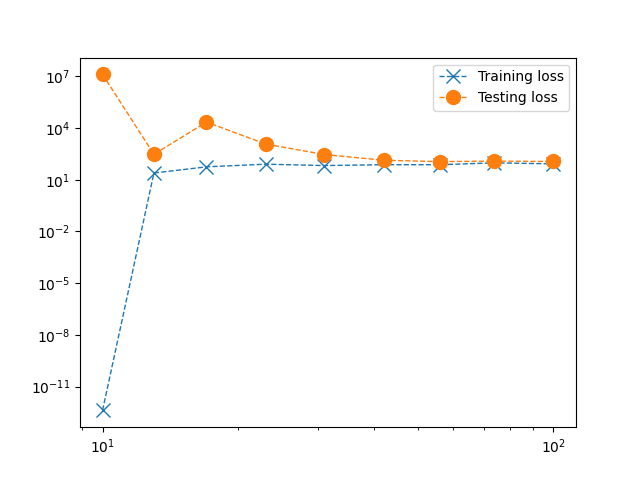

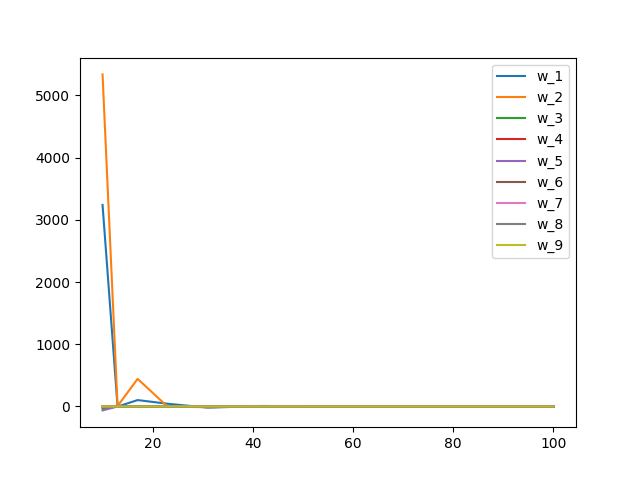

In [33]:
## exercise 2.6.1
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

%matplotlib widget

train1 = np.loadtxt('./data/projectile_1/training_set_1.dat')
test1 = np.loadtxt('./data/projectile_1/test_set_1.dat')

X_train = train1[:, :2]
y_train = train1[:, 2]
X_test = test1[:, :2]
y_test = test1[:, 2]

# Feature engineering
X_train_new = np.zeros((len(X_train), 9))
X_test_new = np.zeros((len(X_test), 9))

ci = 0
for s in range(1, 4):
    for p in range(s+1):
        X_train_new[:, ci] = X_train[:, 0]**(s-p) * X_train[:, 1]**p
        X_test_new[:, ci] = X_test[:, 0]**(s-p) * X_test[:, 1]**p
        # print('s.{} p.{}, q.{}'.format(s, p, s-p))
        ci += 1

# Training set size array
n_train = np.logspace(1, 2, 9).astype(int)

Parameters = []
Training_loss = []
Testing_loss = []
# Training loop
for i, n in enumerate(n_train):
    # Generate training set
    idx = np.random.choice(len(X_train_new), n, replace=False)
    X_train_sub = X_train_new[idx]
    y_train_sub = y_train[idx]
    
    # Train OLS regression model
    ols = LinearRegression()
    ols.fit(X_train_sub, y_train_sub)
    
    # Make a prediction using the testing input
    y_pred_test = ols.predict(X_test_new)
    Testing_loss.append(mean_squared_error(y_test, y_pred_test))
    
    # Make a prediction using the training input
    y_pred_train_sub = ols.predict(X_train_sub)
    Training_loss.append(mean_squared_error(y_train_sub, y_pred_train_sub))
    
    # Store the weights and the intercept
    Parameters.append(ols.coef_)

# Plot the training loss and "true" loss as a function of the training dataset sizes
plt.figure()
plt.clf()
plt.plot(n_train, Training_loss, 'x--', lw=1, ms=10, label='Training loss')
plt.plot(n_train, Testing_loss, 'o--', lw=1, ms=10, label='Testing loss')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

# Plot the weights and the intercept as a function of the training dataset sizes
plt.figure()
plt.clf()
pmt = np.array(Parameters)
for i in range(pmt.shape[1]):
    plt.plot(n_train, pmt[:, i], label='w_{}'.format(i+1))
plt.legend()
plt.show()


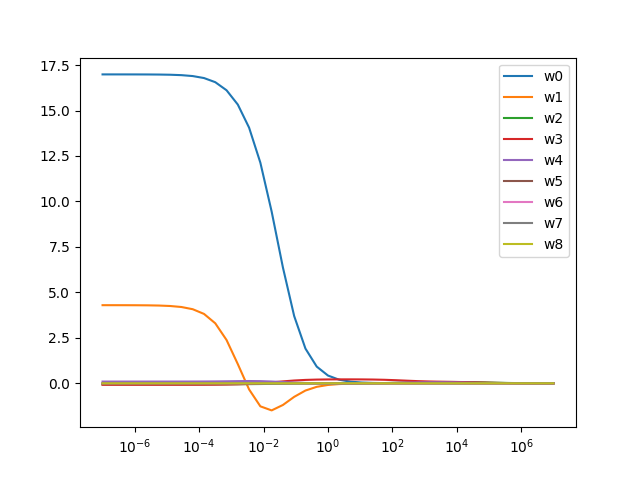

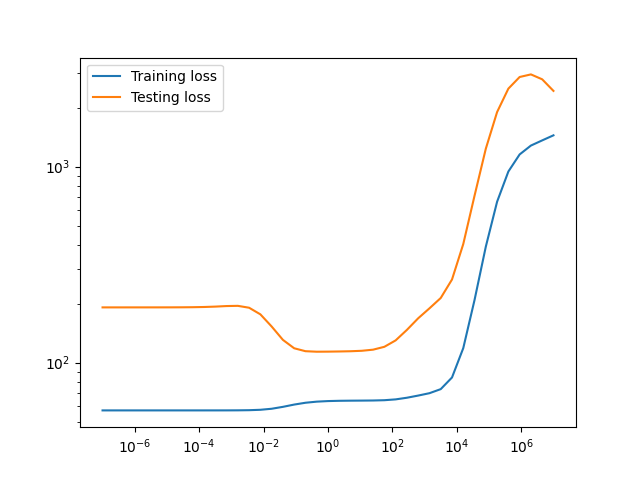

In [42]:
# Exercise 2.6.2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

%matplotlib widget

train1 = np.loadtxt('./data/projectile_1/training_set_1.dat')
test1 = np.loadtxt('./data/projectile_1/test_set_1.dat')

X_train = train1[:, :2]
y_train = train1[:, 2]
X_test = test1[:, :2]
y_test = test1[:, 2]

# Feature engineering
X_train_new = np.zeros((len(X_train), 9))
X_test_new = np.zeros((len(X_test), 9))

ci = 0
for s in range(1, 4):
    for p in range(s+1):
        X_train_new[:, ci] = X_train[:, 0]**(s-p) * X_train[:, 1]**p
        X_test_new[:, ci] = X_test[:, 0]**(s-p) * X_test[:, 1]**p
        # print('s.{} p.{}, q.{}'.format(s, p, s-p))
        ci += 1

N = 20
idx = np.random.choice(len(X_train_new), N, replace=False)
X_train_sub = X_train_new[idx]
y_train_sub = y_train[idx]


Alphas = np.logspace(-7, 7, 41)

Training_loss = []
Testing_loss = []
Weights = []
Intercepts = []
for i, alpha in enumerate(Alphas):
    ridge_model = Ridge(alpha=N*alpha)
    ridge_model.fit(X_train_sub, y_train_sub)
    y_pred_test = ridge_model.predict(X_test_new)
    y_pred_train = ridge_model.predict(X_train_sub)
    Training_loss.append(mean_squared_error(y_train_sub, y_pred_train))
    Testing_loss.append(mean_squared_error(y_test, y_pred_test))
    Weights.append(ridge_model.coef_)
    Intercepts.append(ridge_model.intercept_)

Weights = np.array(Weights)
plt.figure()
plt.clf()
for i in range(Weights.shape[1]):
    plt.plot(Alphas, Weights[:,i], label='w{}'.format(i))
# plt.plot(Alphas, Intercepts, label='Intercepts')
plt.xscale('log')
plt.legend()
plt.show()

plt.figure()
plt.clf()
plt.plot(Alphas, Training_loss, label='Training loss')
plt.plot(Alphas, Testing_loss, label='Testing loss')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()




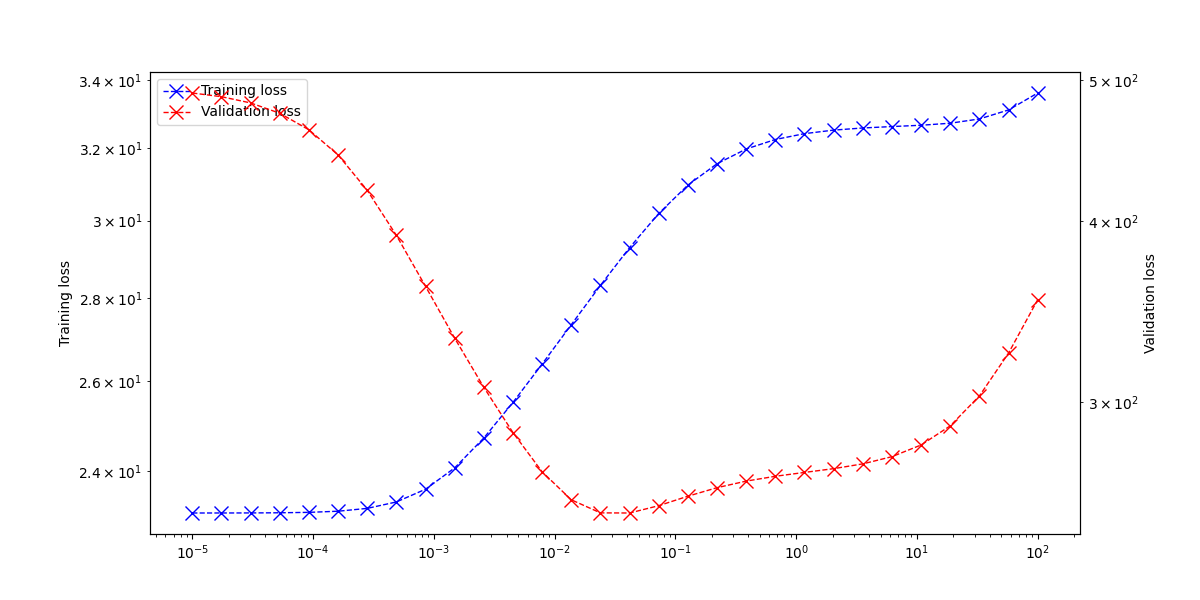

The optimal alpha is:  [0.04175319]
With cross-validation:
The mean squared error on the training set is:  37.85417791992349
The mean squared error on the   test set   is:  214.69925498177793
With all data:
The mean squared error on the training set is:  34.40809216661047
The mean squared error on the   test set   is:  734.6769411801738


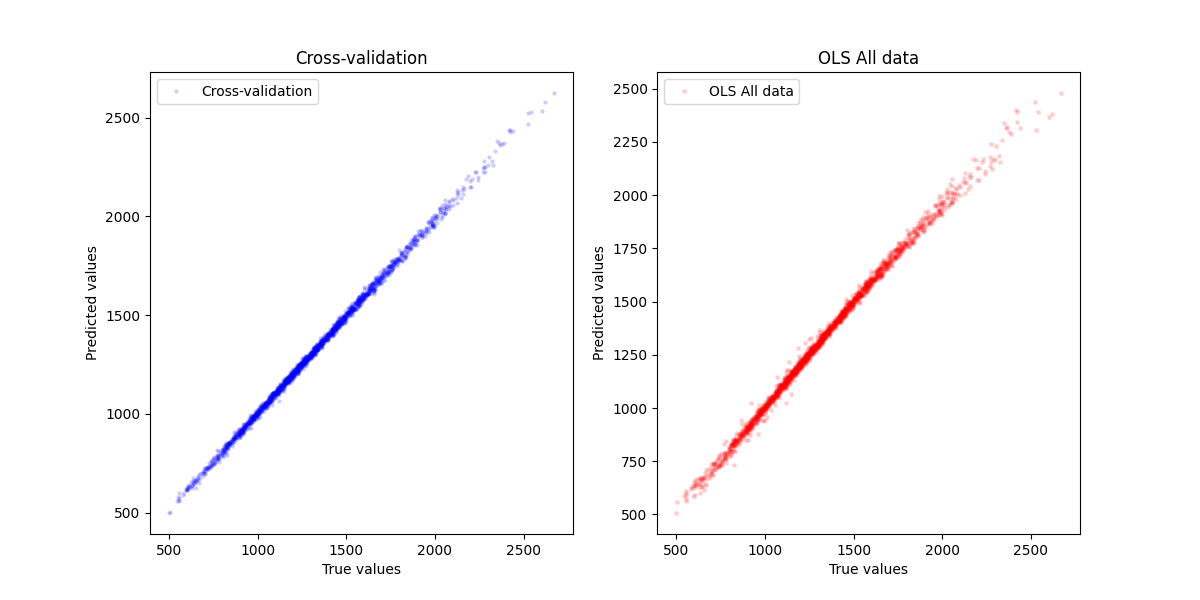

Compare coefficients of the two models
   Terms    |  Cross-validation  |  OLS All data 
vx^1vy^0     |          -3.1425 |         -37.4292
vx^0vy^1     |           2.9500 |          -5.6288
vx^2vy^0     |           0.0352 |           0.3002
vx^1vy^1     |           0.2237 |           0.6010
vx^0vy^2     |          -0.0495 |          -0.1045
vx^3vy^0     |           0.0001 |          -0.0001
vx^2vy^1     |          -0.0009 |          -0.0036
vx^1vy^2     |           0.0008 |           0.0009
vx^0vy^3     |          -0.0000 |           0.0001


In [ ]:
# Exercise 2.6.3
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

%matplotlib widget

# Load and preprocess the data
# Load 100 random samples from training_set_1.dat as training set, use test_set_1.dat as test set

# Read data
train_data = np.loadtxt('./data/projectile_1/training_set_1.dat')    # shape: (N,2)
test_data = np.loadtxt('./data/projectile_1/test_set_1.dat')

X_train = train_data[:, :2]
Y_train = train_data[:, 2]

X_test = test_data[:, :2]
Y_test = test_data[:, 2]

# Feature engineering
X_train_new = np.zeros((len(X_train), 9))
X_test_new = np.zeros((len(X_test), 9))

ci = 0
Terms = []
for s in range(1, 4):
    for p in range(s+1):
        X_train_new[:, ci] = X_train[:, 0]**(s-p) * X_train[:, 1]**p
        X_test_new[:, ci] = X_test[:, 0]**(s-p) * X_test[:, 1]**p
        Terms.append(f'vx^{s-p:d}vy^{p:d}')
        # print('s.{} p.{}, q.{}'.format(s, p, s-p))
        ci += 1

N = 20

# Randomly select 100 points from training set for this exercise
np.random.seed(42)
rand_idx = np.random.choice(train_data.shape[0], N, replace=False)

X_train_sub = X_train_new[rand_idx, :]
Y_train_sub = Y_train[rand_idx]

# 1. Penalty strengths to try
alphas = np.logspace(-5, 2, 30)   

# 2. Set up the $k$ folds of the training set
k = 5
Folds = {'X':[], 'Y':[]}
for i in range(k):
    Folds['X'].append(X_train_sub[i*N//k:(i+1)*N//k, :])
    Folds['Y'].append(Y_train_sub[i*N//k:(i+1)*N//k])

# 3. Loop over each values of penalty strength and compute the associated validation error, as well as the averaged training error.
Training_loss = []
Validation_loss = []
ridge_model = Ridge(alpha=alphas[0])
for alpha in alphas:
    k_train_loss = []
    k_validation_loss = []
    for i in range(k):
        # set up the validation and training folds
        X_val_fold = Folds['X'][i]
        Y_val_fold = Folds['Y'][i]
        X_trn_fold = np.concatenate(Folds['X'][:i] + Folds['X'][i+1:])
        Y_trn_fold = np.concatenate(Folds['Y'][:i] + Folds['Y'][i+1:])
        
        # set up the model with the correct penalty strength
        N_train = Y_trn_fold.shape[0]
        ridge_model.set_params(alpha=N_train*alpha)
        
        # train the model on the training fold
        ridge_model.fit(X_trn_fold, Y_trn_fold)
        
        # make predictions on the training and validation folds
        Y_pred_trn = ridge_model.predict(X_trn_fold)
        Y_pred_val = ridge_model.predict(X_val_fold)
        
        # record the losses
        k_train_loss.append(mean_squared_error(Y_trn_fold, Y_pred_trn))
        k_validation_loss.append(mean_squared_error(Y_val_fold, Y_pred_val))
    
    Training_loss.append(np.mean(k_train_loss))
    Validation_loss.append(np.mean(k_validation_loss))
Training_loss = np.array(Training_loss)
Validation_loss = np.array(Validation_loss)

# 4. plot the validation and training loss as a function of alpha
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xscale('log')
ax1.set_yscale('log')
ln1 = ax1.plot(alphas, Training_loss, 'bx--', lw=1, ms=10, label='Training loss')
ax1.set_ylabel('Training loss', rotation=90)
ax2 = ax1.twinx()
ax2.set_yscale('log')
ln2 = ax2.plot(alphas, Validation_loss, 'rx--', lw=1, ms=10, label='Validation loss')
ax2.set_ylabel('Validation loss', rotation=90)

# Combine legends
lns = ln1 + ln2
labels = [l.get_label() for l in lns]
ax1.legend(lns, labels, loc='best')
plt.show()

# 5. Find the optimal alpha
min_index = np.where(Validation_loss==np.min(Validation_loss))[0]
optimal_alpha = alphas[min_index]
print('The optimal alpha is: ', optimal_alpha)

# 6. Train the model with the optimal alpha on all data
N_sub = X_train_sub.shape[0]
ridge_model.set_params(alpha=N_sub*optimal_alpha)
ridge_model.fit(X_train_sub, Y_train_sub)
Weights_sub = ridge_model.coef_
Intercept_sub = ridge_model.intercept_

# 7. Evaluate the final outcome on the test set
Y_pred_trn_cv = ridge_model.predict(X_train_sub)
mse_trn_cv = mean_squared_error(Y_train_sub, Y_pred_trn_cv)
Y_pred_test_cv = ridge_model.predict(X_test_new)
mse_test_cv = mean_squared_error(Y_test, Y_pred_test_cv)
print('==============================================')
print('With cross-validation:')
print('The mean squared error on the training set is: ', mse_trn_cv)
print('The mean squared error on the   test set   is: ', mse_test_cv)
# print('The weights are: ', Weights_sub)
# print('The intercept is: ', Intercept_sub)
print('==============================================')

# 8. OLS with training set
ols = LinearRegression()
ols.fit(X_train_sub, Y_train_sub)
Y_pred_trn_ols = ols.predict(X_train_sub)
mse_trn_ols = mean_squared_error(Y_train_sub, Y_pred_trn_ols)
Y_pred_test_ols = ols.predict(X_test_new)
mse_test_ols = mean_squared_error(Y_test, Y_pred_test_ols)
print('==============================================')
print('OLS without cross-validation:')
print('The mean squared error on the training set is: ', mse_trn_ols)
print('The mean squared error on the   test set   is: ', mse_test_ols)
# print('The weights are: ', ols.coef_)
# print('The intercept is: ', ols.intercept_)
print('==============================================')

# 9. Compare the performance of the two models
fig, ax = plt.subplots(1, 2,  figsize=(12, 6))

ax[0].plot(Y_test, Y_pred_test_cv, 'bo', alpha=0.2, ms=3, mec='none', label='Cross-validation')
ax[0].legend()
ax[0].set_xlabel('True values')
ax[0].set_ylabel('Predicted values')
ax[0].set_title('Cross-validation')

ax[1].plot(Y_test, Y_pred_test_ols, 'rs', alpha=0.2, ms=3, mec='none', label='OLS All data')
ax[1].legend()
ax[1].set_xlabel('True values')
ax[1].set_ylabel('Predicted values')
ax[1].set_title('OLS All data')

plt.show()

print('==============================================')
print('Compare coefficients of the two models')
print('   Terms    |  Cross-validation  |  OLS All data ')
for i in range(len(Terms)):
    print(f'{Terms[i]:12s} | {Weights_sub[i]:16.4f} | {ols.coef_[i]:16.4f}')
print('==============================================')



